**Import Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


**Load and Inspect the Data**

In [2]:
# Load the data
covid_19_data = pd.read_csv('covid_19_data (1).csv')
covid19_line_list_data = pd.read_csv('COVID19_line_list_data_modified (1).csv')

# Display the first few rows
print(covid_19_data.head())
print(covid19_line_list_data.head())


   SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1       1/22/2020          Anhui  Mainland China  1/22/2020 17:00   
1    2       1/22/2020        Beijing  Mainland China  1/22/2020 17:00   
2    3       1/22/2020      Chongqing  Mainland China  1/22/2020 17:00   
3    4       1/22/2020         Fujian  Mainland China  1/22/2020 17:00   
4    5       1/22/2020          Gansu  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0          1       0          0  
1         14       0          0  
2          6       0          0  
3          1       0          0  
4          0       0          0  
   id  case_in_country reporting date  Unnamed: 3  \
0   1              NaN      1/20/2020         NaN   
1   2              NaN      1/20/2020         NaN   
2   3              NaN      1/21/2020         NaN   
3   4              NaN      1/21/2020         NaN   
4   5              NaN      1/21/2020         NaN   

                                

**Clean and Preprocess the Data**

In [3]:
# Drop unnecessary columns
covid_19_data = covid_19_data.drop(columns=['SNo', 'Last Update'])

# Fill missing values
covid_19_data['Province/State'].fillna('Unknown', inplace=True)

# Convert data types
covid_19_data['ObservationDate'] = pd.to_datetime(covid_19_data['ObservationDate'])
covid_19_data[['Confirmed', 'Deaths', 'Recovered']] = covid_19_data[['Confirmed', 'Deaths', 'Recovered']].astype(int)

print(covid_19_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8509 entries, 0 to 8508
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ObservationDate  8509 non-null   datetime64[ns]
 1   Province/State   8509 non-null   object        
 2   Country/Region   8509 non-null   object        
 3   Confirmed        8509 non-null   int32         
 4   Deaths           8509 non-null   int32         
 5   Recovered        8509 non-null   int32         
dtypes: datetime64[ns](1), int32(3), object(2)
memory usage: 299.3+ KB
None


Cleaning covid19_line_list_data


In [4]:
# Drop unnecessary columns
covid19_line_list_data = covid19_line_list_data.drop(columns=['Unnamed: 3'])

# Convert date columns to datetime objects
date_columns = ['reporting date', 'symptom_onset', 'hosp_visit_date', 'exposure_start', 'exposure_end']
for col in date_columns:
    covid19_line_list_data[col] = pd.to_datetime(covid19_line_list_data[col], errors='coerce')

# Fill missing values
covid19_line_list_data.fillna({'case_in_country': 0, 'gender': 'unknown', 'age': 0, 'visiting Wuhan': 0, 'from Wuhan': 0, 'death': 0, 'recovered': 0, 'symptom': 'unknown'}, inplace=True)

# Convert numeric columns to proper types
numeric_columns = ['case_in_country', 'age', 'visiting Wuhan', 'from Wuhan', 'death', 'recovered']
covid19_line_list_data[numeric_columns] = covid19_line_list_data[numeric_columns].apply(pd.to_numeric, errors='coerce')

print(covid19_line_list_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1085 non-null   int64         
 1   case_in_country        1085 non-null   float64       
 2   reporting date         1084 non-null   datetime64[ns]
 3   summary                1080 non-null   object        
 4   location               1085 non-null   object        
 5   country                1085 non-null   object        
 6   gender                 1085 non-null   object        
 7   age                    1085 non-null   float64       
 8   symptom_onset          563 non-null    datetime64[ns]
 9   If_onset_approximated  560 non-null    float64       
 10  hosp_visit_date        506 non-null    datetime64[ns]
 11  exposure_start         128 non-null    datetime64[ns]
 12  exposure_end           341 non-null    datetime64[ns]
 13  vis

**Data Analysis and Clustering**

**i)Identify the Highest and Second Highest Affected Areas**

In [5]:
# Group by Country/Region and sum the confirmed cases
country_data = covid_19_data.groupby('Country/Region').agg({'Confirmed': 'sum'}).reset_index()
highest_affected_area = country_data.sort_values(by='Confirmed', ascending=False).iloc[0]
second_highest_affected_area = country_data.sort_values(by='Confirmed', ascending=False).iloc[1]

print("Highest affected area:", highest_affected_area)
print("Second highest affected area:", second_highest_affected_area)


Highest affected area: Country/Region    Mainland China
Confirmed                3606533
Name: 116, dtype: object
Second highest affected area: Country/Region     Italy
Confirmed         571924
Name: 95, dtype: object


**ii) Mortality vs. Recovery Ratio**

In [6]:
# Calculate mortality vs recovery ratio
total_deaths = covid_19_data['Deaths'].sum()
total_recovered = covid_19_data['Recovered'].sum()
mortality_recovery_ratio = total_deaths / total_recovered if total_recovered != 0 else np.nan

print("Mortality vs. Recovery Ratio:", mortality_recovery_ratio)


Mortality vs. Recovery Ratio: 0.10392256335788293


**iii) General Tendency Towards Particular Age, Gender, or Random**

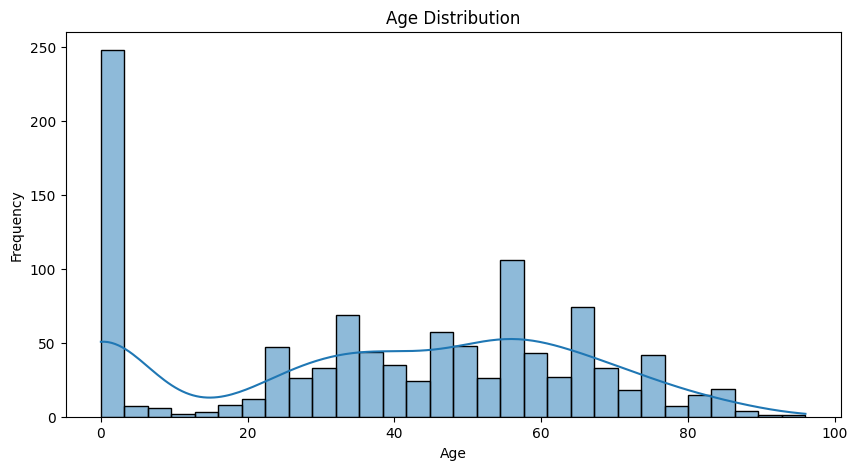

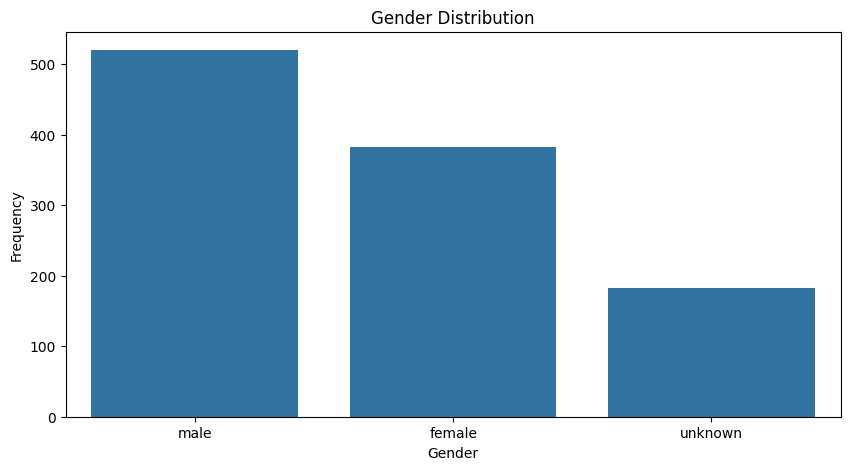

In [8]:
# Age and gender distribution
plt.figure(figsize=(10, 5))
sns.histplot(covid19_line_list_data['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

gender_counts = covid19_line_list_data['gender'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()


**iv) Mortality Rate Among Different Age Groups**

In [9]:
# Define age groups
age_bins = [0, 18, 30, 50, 70, 100]
age_labels = ['0-18', '19-30', '31-50', '51-70', '71+']
covid19_line_list_data['age_group'] = pd.cut(covid19_line_list_data['age'], bins=age_bins, labels=age_labels, right=False)

# Calculate mortality rate for each age group
age_group_mortality = covid19_line_list_data.groupby('age_group').agg({'death': 'sum', 'case_in_country': 'count'})
age_group_mortality['mortality_rate'] = age_group_mortality['death'] / age_group_mortality['case_in_country']

print(age_group_mortality[['mortality_rate']])


           mortality_rate
age_group                
0-18             0.000000
19-30            0.000000
31-50            0.010870
51-70            0.053292
71+              0.181818


 **Develop a Simple User Interface**

In [13]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
covid_19_data = pd.read_csv('covid_19_data (1).csv')
covid19_line_list_data = pd.read_csv('COVID19_line_list_data_modified (1).csv')

# Data Cleaning and Preprocessing
def preprocess_data():
    # Drop unnecessary columns
    covid_19_data.drop(columns=['SNo', 'Last Update'], inplace=True)
    covid19_line_list_data.drop(columns=['Unnamed: 3'], inplace=True)
    
    # Fill missing values
    covid_19_data['Province/State'].fillna('Unknown', inplace=True)
    covid19_line_list_data.fillna({'case_in_country': 0, 'gender': 'unknown', 'age': 0, 
                                   'visiting Wuhan': 0, 'from Wuhan': 0, 'death': 0, 
                                   'recovered': 0, 'symptom': 'unknown'}, inplace=True)
    
    # Convert data types
    covid_19_data['ObservationDate'] = pd.to_datetime(covid_19_data['ObservationDate'])
    covid_19_data[['Confirmed', 'Deaths', 'Recovered']] = covid_19_data[['Confirmed', 'Deaths', 'Recovered']].astype(int)
    
    date_columns = ['reporting date', 'symptom_onset', 'hosp_visit_date', 'exposure_start', 'exposure_end']
    for col in date_columns:
        covid19_line_list_data[col] = pd.to_datetime(covid19_line_list_data[col], errors='coerce')
    
    numeric_columns = ['case_in_country', 'age', 'visiting Wuhan', 'from Wuhan', 'death', 'recovered']
    covid19_line_list_data[numeric_columns] = covid19_line_list_data[numeric_columns].apply(pd.to_numeric, errors='coerce')
    
    # Define age groups
    age_bins = [0, 18, 30, 50, 70, 100]
    age_labels = ['0-18', '19-30', '31-50', '51-70', '71+']
    covid19_line_list_data['age_group'] = pd.cut(covid19_line_list_data['age'], bins=age_bins, labels=age_labels, right=False)

preprocess_data()

# Highest and Second Highest Affected Areas
def get_highest_affected_areas():
    country_data = covid_19_data.groupby('Country/Region').agg({'Confirmed': 'sum'}).reset_index()
    highest_affected_area = country_data.sort_values(by='Confirmed', ascending=False).iloc[0]
    second_highest_affected_area = country_data.sort_values(by='Confirmed', ascending=False).iloc[1]
    return highest_affected_area, second_highest_affected_area

highest_affected_area, second_highest_affected_area = get_highest_affected_areas()

# Mortality vs Recovery Ratio
def get_mortality_recovery_ratio():
    total_deaths = covid_19_data['Deaths'].sum()
    total_recovered = covid_19_data['Recovered'].sum()
    mortality_recovery_ratio = total_deaths / total_recovered if total_recovered != 0 else np.nan
    return mortality_recovery_ratio

mortality_recovery_ratio = get_mortality_recovery_ratio()

# Age and Gender Distribution
def plot_age_gender_distribution():
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    sns.histplot(covid19_line_list_data['age'], bins=30, kde=True, ax=ax[0])
    ax[0].set_title('Age Distribution')
    ax[0].set_xlabel('Age')
    ax[0].set_ylabel('Frequency')

    gender_counts = covid19_line_list_data['gender'].value_counts()
    sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=ax[1])
    ax[1].set_title('Gender Distribution')
    ax[1].set_xlabel('Gender')
    ax[1].set_ylabel('Frequency')
    
    return fig

# Mortality Rate Among Different Age Groups
def get_age_group_mortality():
    age_group_mortality = covid19_line_list_data.groupby('age_group').agg({'death': 'sum', 'case_in_country': 'count'})
    age_group_mortality['mortality_rate'] = age_group_mortality['death'] / age_group_mortality['case_in_country']
    return age_group_mortality

age_group_mortality = get_age_group_mortality()

# Streamlit Interface
st.title("COVID-19 Data Analysis")

# Highest and Second Highest Affected Areas
st.header("Highest and Second Highest Affected Areas")
st.write(f"Highest affected area: {highest_affected_area['Country/Region']} with {highest_affected_area['Confirmed']} confirmed cases")
st.write(f"Second highest affected area: {second_highest_affected_area['Country/Region']} with {second_highest_affected_area['Confirmed']} confirmed cases")

# Mortality vs Recovery Ratio
st.header("Mortality vs Recovery Ratio")
st.write(f"Mortality vs. Recovery Ratio: {mortality_recovery_ratio}")

# Age and Gender Distribution
st.header("Age and Gender Distribution")
fig = plot_age_gender_distribution()
st.pyplot(fig)

# Mortality rate among different age groups
st.header("Mortality Rate Among Different Age Groups")
st.write(age_group_mortality[['mortality_rate']])

